In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

In [7]:
df = pd.read_csv("C:/Users/tiffa/Desktop/projects/Data/DS project 2/Mall_Customers.csv")

In [8]:
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [9]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


# Univariate Analysis

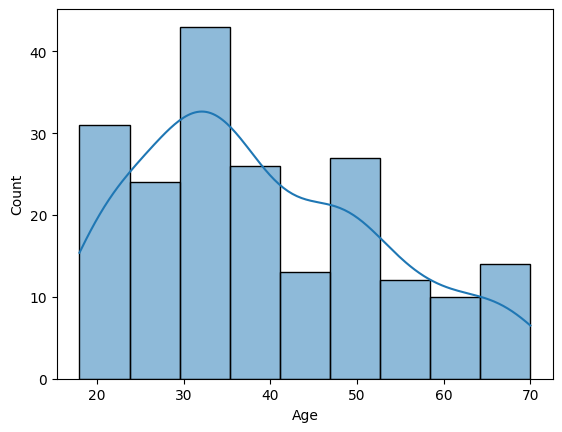

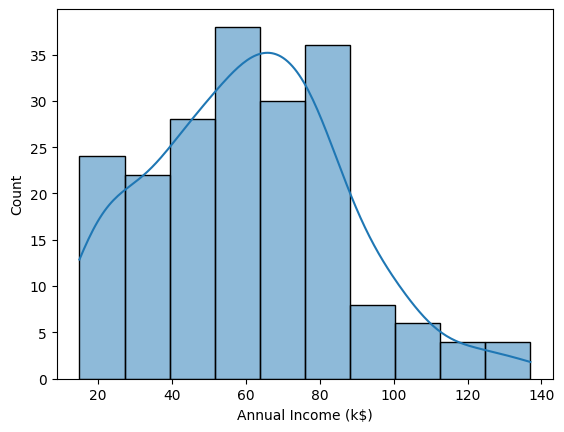

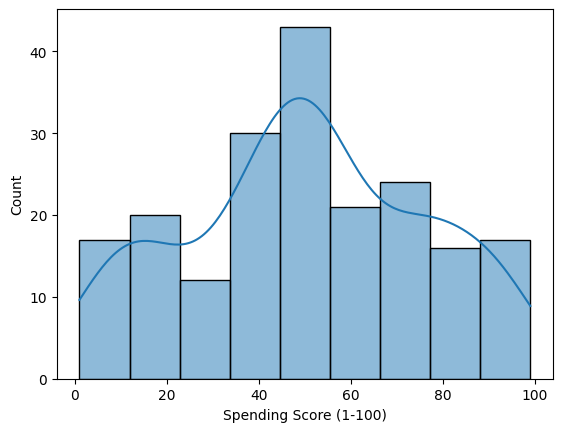

In [17]:
col = ['Age','Annual Income (k$)', 'Spending Score (1-100)']
for c in col:
    plt.figure()
    sns.histplot(df[c],kde=True)

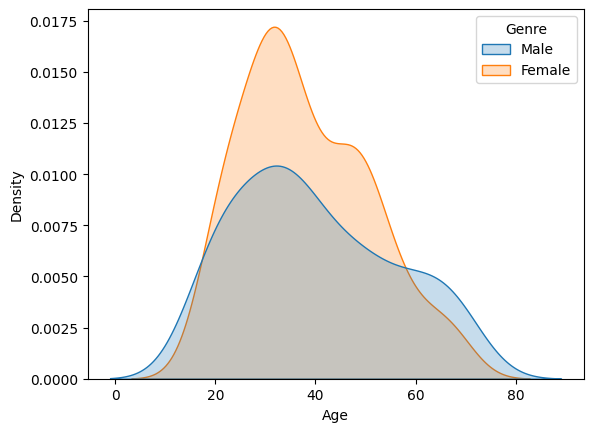

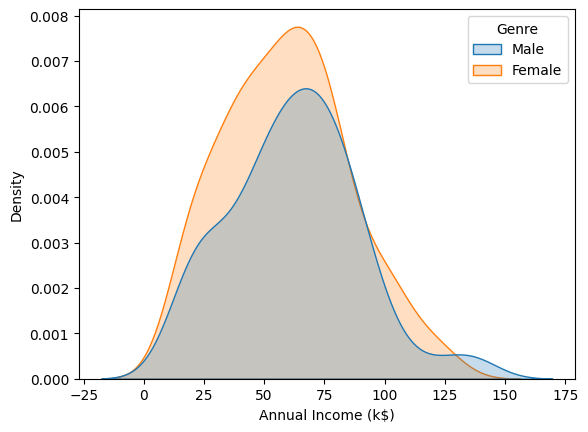

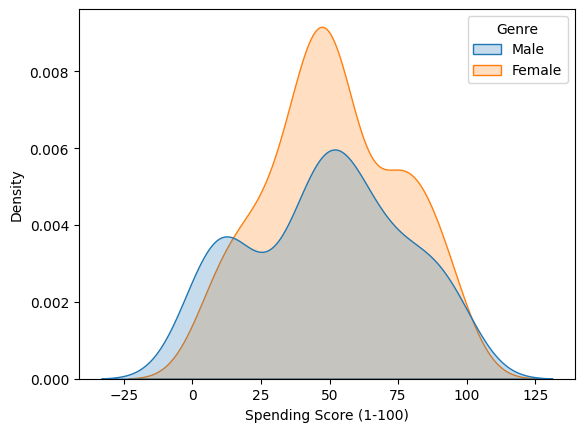

In [ ]:
for c in col:
    plt.figure()
    sns.kdeplot(data = df, x = c,fill=True,hue='Genre')

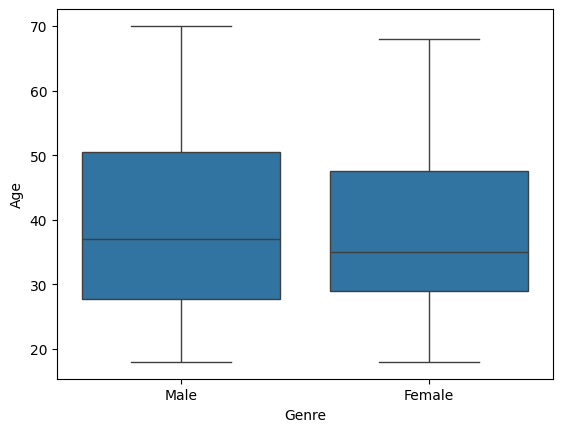

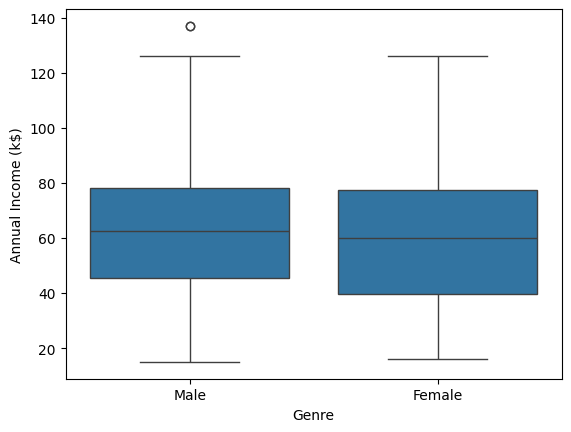

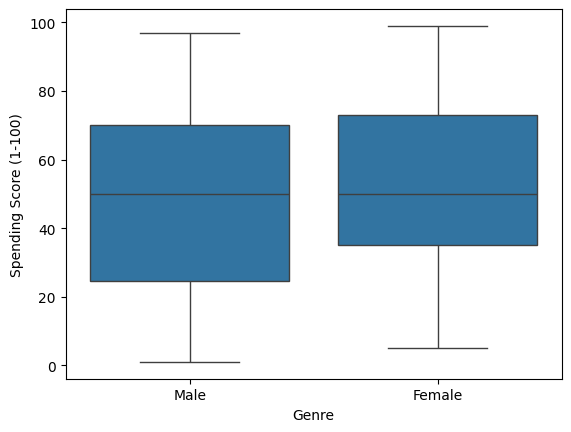

In [ ]:
for c in col:
    plt.figure()
    sns.boxplot(data = df,x = 'Genre',y = c)

In [38]:
df['Genre'].value_counts(normalize=True)

Genre
Female    0.56
Male      0.44
Name: proportion, dtype: float64

# Bivariate Analysis

<Axes: xlabel='Annual Income (k$)', ylabel='Spending Score (1-100)'>

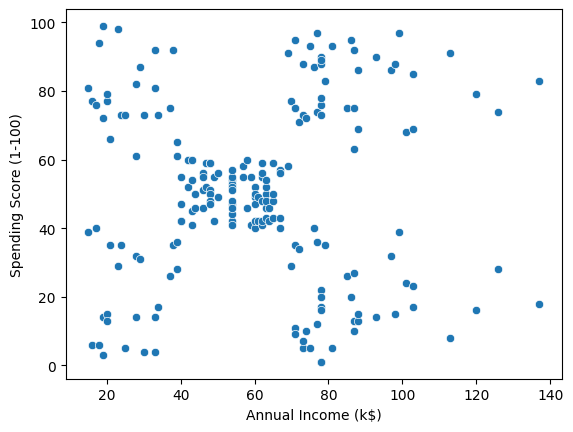

In [39]:
sns.scatterplot(data=df, x='Annual Income (k$)', y='Spending Score (1-100)')

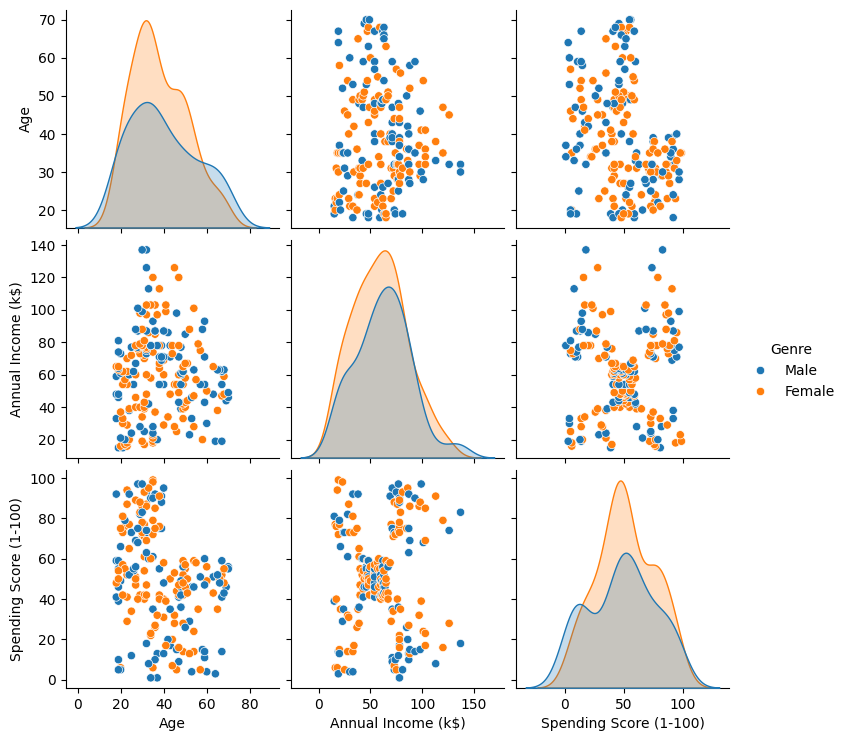

In [ ]:
#df =df.drop('CustomerID',axis=1)
sns.pairplot(df,hue='Genre')

In [46]:
df.groupby(['Genre'])[col].mean()

,Age,Annual Income (k$),Spending Score (1-100)
Genre,,,
Female,38.098214,59.250000,51.526786
Male,39.806818,62.227273,48.511364


In [48]:
df.corr(numeric_only=True)

,Age,Annual Income (k$),Spending Score (1-100)
Age,1.000000,-0.012398,-0.327227
Annual Income (k$),-0.012398,1.000000,0.009903
Spending Score (1-100),-0.327227,0.009903,1.000000


<Axes: >

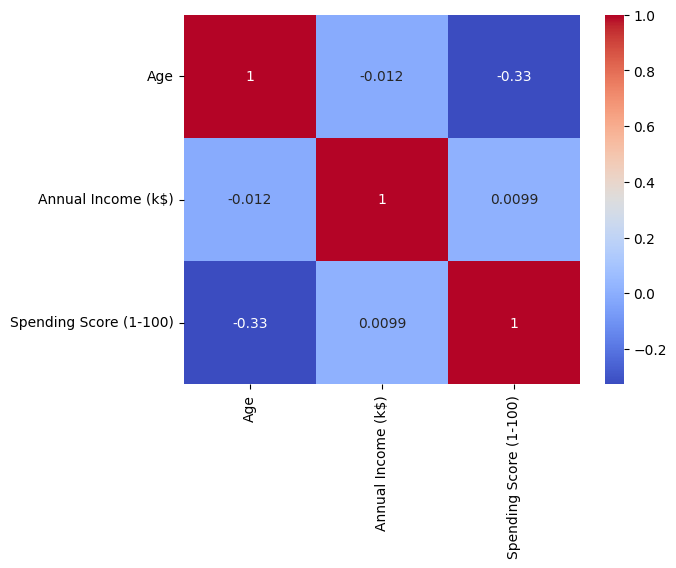

In [50]:
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap='coolwarm')

# Clustering - Univariate, Bivariate, Multivariate

In [66]:
clustering1 = KMeans(n_clusters = 3)

In [67]:
clustering1.fit(df[['Annual Income (k$)']])

,n_clusters,3
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,None
,copy_x,True
,algorithm,'lloyd'


In [68]:
clustering1.labels_

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2], dtype=int32)

In [69]:
df['Income Cluster'] = clustering1.labels_
df.head()

,Genre,Age,Annual Income (k$),Spending Score (1-100),Income Cluster
0,Male,19,15,39,0
1,Male,21,15,81,0
2,Female,20,16,6,0
3,Female,23,16,77,0
4,Female,31,17,40,0


In [70]:
df['Income Cluster'].value_counts()

Income Cluster
1    92
0    86
2    22
Name: count, dtype: int64

In [ ]:
clustering1.inertia_

25341.28587186322

In [63]:
inertia_scores = []
for i in range(1,7):
    kmeans = KMeans(n_clusters=i)
    kmeans.fit(df[['Annual Income (k$)']])
    inertia_scores.append(kmeans.inertia_)

In [64]:
inertia_scores

[137277.28000000003,
 48660.88888888889,
 25640.457784396833,
 14721.866979949875,
 8481.496190476191,
 5727.338046202462]

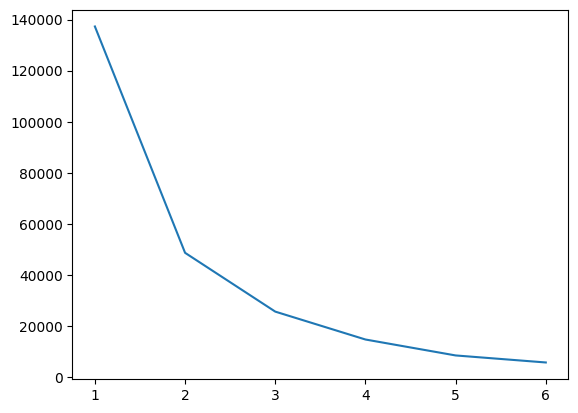

In [65]:
plt.plot(range(1,7),inertia_scores)

In [72]:
df.columns

Index(['Genre', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)',
       'Income Cluster'],
      dtype='object')

In [76]:
df.groupby('Income Cluster')[col].mean()

,Age,Annual Income (k$),Spending Score (1-100)
Income Cluster,,,
0,40.023256,36.348837,50.081395
1,38.065217,71.804348,49.880435
2,37.545455,108.181818,52.000000


# Bivariate Clustering

In [86]:
clustering2 = KMeans(n_clusters=5)
clustering2.fit(df[['Annual Income (k$)','Spending Score (1-100)']])
clustering2.labels_
df['Spending and Income Cluster'] = clustering2.labels_
df.head()

,Genre,Age,Annual Income (k$),Spending Score (1-100),Income Cluster,Spending and Income Cluster
0,Male,19,15,39,0,1
1,Male,21,15,81,0,4
2,Female,20,16,6,0,1
3,Female,23,16,77,0,4
4,Female,31,17,40,0,1


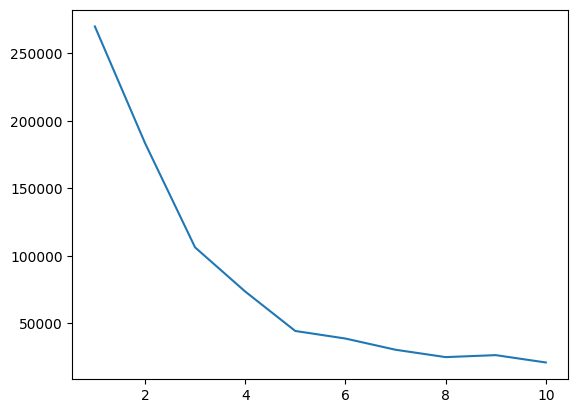

In [83]:
inertia_scores2 = []
for i in range(1,11):
    kmeans = KMeans(n_clusters=i)
    kmeans.fit(df[['Annual Income (k$)','Spending Score (1-100)']])
    inertia_scores2.append(kmeans.inertia_)
plt.plot(range(1,11),inertia_scores2)

In [91]:
centers = pd.DataFrame(clustering2.cluster_centers_)
centers.columns = ['x','y']

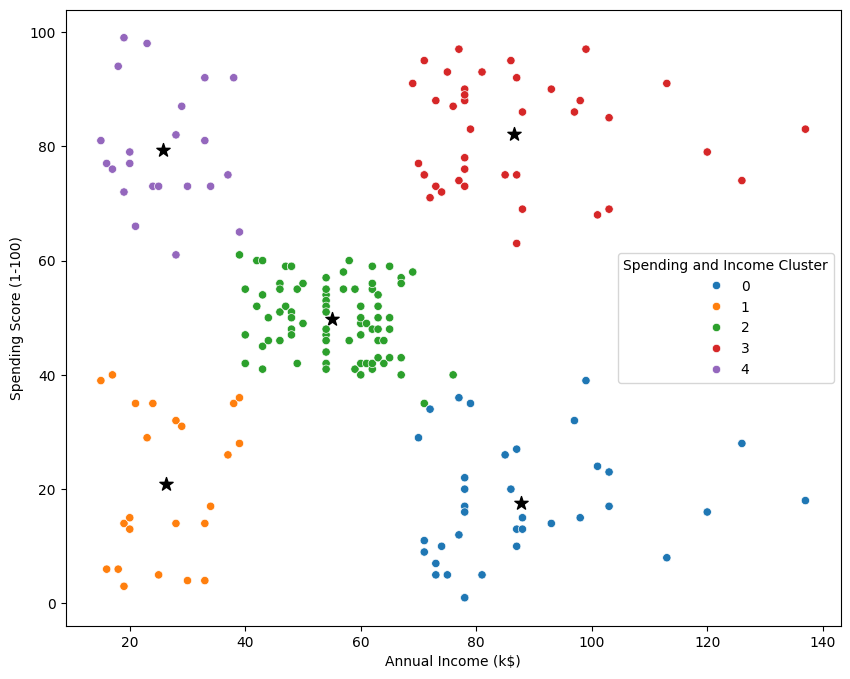

In [123]:
plt.figure(figsize=(10,8))
plt.scatter(x=centers['x'],y=centers['y'],s=100,c='black',marker='*')
sns.scatterplot(data=df,x='Annual Income (k$)',y='Spending Score (1-100)',hue='Spending and Income Cluster', palette='tab10')
plt.savefig('Bivariate_clustering.png')

In [95]:
pd.crosstab(df['Spending and Income Cluster'],df['Genre'],normalize='index')

Genre,Female,Male
Spending and Income Cluster,,
0,0.472222,0.527778
1,0.608696,0.391304
2,0.587500,0.412500
3,0.538462,0.461538
4,0.590909,0.409091


In [97]:
df.groupby('Spending and Income Cluster')[col].mean()

,Age,Annual Income (k$),Spending Score (1-100)
Spending and Income Cluster,,,
0,40.666667,87.750000,17.583333
1,45.217391,26.304348,20.913043
2,42.937500,55.087500,49.712500
3,32.692308,86.538462,82.128205
4,25.272727,25.727273,79.363636


# Multivariate Clustering

In [113]:
from sklearn.preprocessing import StandardScaler

In [116]:
scale = StandardScaler()

In [100]:
df.head()

,Genre,Age,Annual Income (k$),Spending Score (1-100),Income Cluster,Spending and Income Cluster
0,Male,19,15,39,0,1
1,Male,21,15,81,0,4
2,Female,20,16,6,0,1
3,Female,23,16,77,0,4
4,Female,31,17,40,0,1


In [102]:
dff = pd.get_dummies(df,drop_first=True)
dff.head()

,Age,Annual Income (k$),Spending Score (1-100),Income Cluster,Spending and Income Cluster,Genre_Male
0,19,15,39,0,1,True
1,21,15,81,0,4,True
2,20,16,6,0,1,False
3,23,16,77,0,4,False
4,31,17,40,0,1,False


In [104]:
dff.columns

Index(['Age', 'Annual Income (k$)', 'Spending Score (1-100)', 'Income Cluster',
       'Spending and Income Cluster', 'Genre_Male'],
      dtype='object')

In [106]:
dff = dff[['Age', 'Annual Income (k$)', 'Spending Score (1-100)', 'Genre_Male']]
dff.head()

,Age,Annual Income (k$),Spending Score (1-100),Genre_Male
0,19,15,39,True
1,21,15,81,True
2,20,16,6,False
3,23,16,77,False
4,31,17,40,False


In [117]:
dff = scale.fit_transform(dff)

In [120]:
dff = pd.DataFrame(scale.fit_transform(dff))
dff.head()

,0,1,2,3
0,-1.424569,-1.738999,-0.434801,1.128152
1,-1.281035,-1.738999,1.195704,1.128152
2,-1.352802,-1.700830,-1.715913,-0.886405
3,-1.137502,-1.700830,1.040418,-0.886405
4,-0.563369,-1.662660,-0.395980,-0.886405


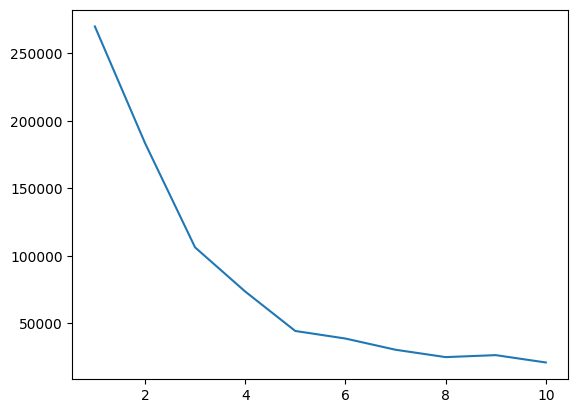

In [121]:
inertia_scores3 = []
for i in range(1,11):
    kmeans = KMeans(n_clusters=i)
    kmeans.fit(dff)
    inertia_scores3.append(kmeans.inertia_)
plt.plot(range(1,11),inertia_scores2)

We confirm here 5 is the right number of clusters

In [122]:
df.to_csv('Clustering.csv')